# DSA 210 Term Project — Machine Learning Methods

The main machine learning goal is:

> Predict running performance from training/session features.

In this project, running performance is represented by **average pace in minutes per kilometer**. A lower pace value means a faster run.

We will apply two ML tasks:

1. **Regression:** predict exact `Avg Pace` as a numeric value.
2. **Classification:** classify a run as `fast` or `slow` based on the median pace.

These models are not meant to be professional coaching tools. They are used to demonstrate how ML can be applied to a personal fitness dataset.


In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

pd.set_option("display.max_columns", None)


## 1. Load the dataset

The dataset was exported from Garmin and contains individual running activities.

Each row is one running activity. The most important column for this ML section is `Avg Pace`, because it represents running performance.


In [4]:
# Load the Garmin running dataset
# The CSV file should be in the same folder as this notebook.

df = pd.read_csv("Garmin Running Dataset.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (509, 36)


,Activity Type,Date,Favorite,Title,Distance,Calories,Time,Avg HR,Max HR,Aerobic TE,Avg Run Cadence,Max Run Cadence,Avg Pace,Best Pace,Total Ascent,Total Descent,Avg Stride Length,Avg Vertical Ratio,Avg Vertical Oscillation,Avg Ground Contact Time,Avg GAP,Normalized Power® (NP®),Training Stress Score®,Avg Power,Max Power,Steps,Body Battery Drain,Min Temp,Decompression,Best Lap Time,Number of Laps,Max Temp,Moving Time,Elapsed Time,Min Elevation,Max Elevation
0,Running,2026-03-14 16:29:29,False,Tuzla Running,5.08,451,00:32:11,164,177,3.9,147,152,6:20,5:40,38,41,1.07,8.8,9.4,320,6:21,362,0.0,359,463,"4,736",-11,--,No,00:00:27.5,6,--,00:32:10,00:32:11,128,140
1,Treadmill Running,2026-03-08 17:14:19,False,Treadmill Running,5.00,470,00:33:22,166,176,3.8,141,150,6:40,6:16,--,--,1.08,8.7,9.3,338,--,329,0.0,326,369,"4,688",-9,--,No,00:00:19.0,6,--,00:32:58,00:33:22,--,--
2,Running,2026-02-19 16:52:23,False,Tuzla Running,5.01,459,00:32:58,165,173,3.2,148,150,6:35,5:02,22,25,1.03,8.9,9.2,321,6:36,344,0.0,341,465,"4,852",-8,--,No,00:00:04.0,6,--,00:32:54,00:32:58,130,140
3,Treadmill Running,2026-02-14 15:25:14,False,Treadmill Running,6.50,646,00:45:17,165,179,3.7,138,221,6:58,6:08,--,--,1.06,8.6,9.1,335,--,327,0.0,311,376,"6,248",-10,--,No,00:04:18.0,7,--,00:44:49,00:45:17,--,--
4,Treadmill Running,2026-02-12 16:43:56,False,Treadmill Running,6.06,614,00:46:22,161,177,3.6,130,240,7:39,6:08,--,--,1.00,8.3,8.3,335,--,306,0.0,262,373,"6,040",-11,--,No,00:00:55.1,7,--,00:45:31,00:46:22,--,--


## 2. Data cleaning for machine learning

Garmin exports some missing values as `"--"`, so we convert them to `NaN`.

Also, `Avg Pace` is stored as a time-like string such as `"6:20"`. For machine learning, we need a numeric target, so we convert it into **minutes per kilometer**.

Example:

- `"6:20"` becomes `6.333`
- `"7:30"` becomes `7.500`

This new numeric column will be called `avg_pace_min_per_km`.


In [5]:
# Replace Garmin missing-value marker with actual NaN
df = df.replace("--", np.nan)

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

def pace_to_minutes(pace):
    """
    Converts pace strings such as '6:20' into numeric minutes.
    '6:20' means 6 minutes and 20 seconds per kilometer.
    """
    if pd.isna(pace):
        return np.nan

    pace = str(pace).strip()
    parts = pace.split(":")

    try:
        if len(parts) == 2:
            minutes = int(parts[0])
            seconds = int(parts[1])
            return minutes + seconds / 60
        elif len(parts) == 3:
            hours = int(parts[0])
            minutes = int(parts[1])
            seconds = int(parts[2])
            return hours * 60 + minutes + seconds / 60
        else:
            return float(pace)
    except:
        return np.nan

# Create numeric target variable
df["avg_pace_min_per_km"] = df["Avg Pace"].apply(pace_to_minutes)

# Convert numeric-looking columns to numeric values
non_numeric_cols = [
    "Activity Type", "Date", "Favorite", "Title",
    "Avg Pace", "Best Pace", "Avg GAP",
    "Decompression", "Time", "Best Lap Time",
    "Moving Time", "Elapsed Time"
]

for col in df.columns:
    if col not in non_numeric_cols:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .replace({"nan": np.nan})
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

print(df[["Date", "Activity Type", "Distance", "Avg Pace", "avg_pace_min_per_km"]].head())
print("\nMissing target values:", df["avg_pace_min_per_km"].isna().sum())


                 Date      Activity Type  Distance Avg Pace  \
0 2026-03-14 16:29:29            Running      5.08     6:20   
1 2026-03-08 17:14:19  Treadmill Running      5.00     6:40   
2 2026-02-19 16:52:23            Running      5.01     6:35   
3 2026-02-14 15:25:14  Treadmill Running      6.50     6:58   
4 2026-02-12 16:43:56  Treadmill Running      6.06     7:39   

   avg_pace_min_per_km  
0             6.333333  
1             6.666667  
2             6.583333  
3             6.966667  
4             7.650000  

Missing target values: 0


## 3. Feature engineering

We create additional variables that may help the model understand training context.

Important engineered features:

- `days_since_start`: how many days passed since the first run
- `days_since_last_run`: rest/inactivity gap before the run
- `break_flag`: whether the previous gap was longer than 14 days
- `weekly_frequency`: number of runs in the same year-week
- `is_treadmill`: whether the activity was a treadmill run

A key correction: weekly frequency should be grouped by **year + week**, not only week number. Otherwise, week 10 of 2021 and week 10 of 2025 would incorrectly be treated as the same week.


In [6]:
# Sort chronologically before creating time-based features
df_ml = df.sort_values("Date").reset_index(drop=True)

# Date-based features
df_ml["year"] = df_ml["Date"].dt.year
df_ml["month"] = df_ml["Date"].dt.month
df_ml["day_of_week"] = df_ml["Date"].dt.dayofweek
df_ml["days_since_start"] = (df_ml["Date"] - df_ml["Date"].min()).dt.days

# Gap between consecutive runs
df_ml["days_since_last_run"] = df_ml["Date"].diff().dt.days
df_ml["days_since_last_run"] = df_ml["days_since_last_run"].fillna(0)

# Flag long breaks
df_ml["break_flag"] = (df_ml["days_since_last_run"] > 14).astype(int)

# Weekly frequency using year-week, not only week number
df_ml["year_week"] = df_ml["Date"].dt.to_period("W")
weekly_frequency = df_ml.groupby("year_week").size()
df_ml["weekly_frequency"] = df_ml["year_week"].map(weekly_frequency).astype(int)

# Treadmill indicator
df_ml["is_treadmill"] = (
    df_ml["Activity Type"]
    .astype(str)
    .str.contains("Treadmill", case=False, na=False)
    .astype(int)
)

df_ml[[
    "Date", "Activity Type", "avg_pace_min_per_km",
    "days_since_last_run", "break_flag", "weekly_frequency", "is_treadmill"
]].head()


,Date,Activity Type,avg_pace_min_per_km,days_since_last_run,break_flag,weekly_frequency,is_treadmill
0,2020-07-18 06:43:49,Running,11.966667,0.0,0,1,0
1,2020-07-20 06:27:02,Running,8.933333,1.0,0,3,0
2,2020-07-21 06:36:02,Running,8.750000,1.0,0,3,0
3,2020-07-24 06:42:05,Running,9.100000,3.0,0,3,0
4,2020-07-27 06:16:10,Running,11.066667,2.0,0,2,0


## 4. Define target and features

The target is:

```python
avg_pace_min_per_km
```

This is a regression target because it is continuous.

We exclude obvious leakage columns such as:

- `Time`
- `Moving Time`
- `Elapsed Time`
- `Avg Pace`
- `Best Pace`
- `Avg GAP`

These columns are too directly related to the target. For example, pace is mathematically related to time and distance, so using `Time` would make the prediction artificially easy.


In [7]:
# Target variable
target = "avg_pace_min_per_km"

# Features used by the ML models
feature_cols = [
    "Activity Type",
    "Distance", "Calories", "Avg HR", "Max HR", "Aerobic TE",
    "Avg Run Cadence", "Max Run Cadence",
    "Total Ascent", "Total Descent",
    "Avg Stride Length", "Avg Vertical Ratio", "Avg Vertical Oscillation",
    "Avg Ground Contact Time",
    "Normalized Power® (NP®)", "Avg Power", "Max Power",
    "Steps", "Body Battery Drain", "Number of Laps",
    "Min Elevation", "Max Elevation",
    "year", "month", "day_of_week", "days_since_start",
    "days_since_last_run", "break_flag", "weekly_frequency", "is_treadmill"
]

# Keep rows with a valid target
model_data = df_ml.dropna(subset=[target]).copy()

X = model_data[feature_cols]
y = model_data[target]

print("ML dataset shape:", X.shape)
print("Target summary:")
display(y.describe())


ML dataset shape: (509, 30)
Target summary:


,avg_pace_min_per_km
count,509.000000
mean,7.522888
std,1.695677
min,5.716667
25%,6.366667
50%,6.666667
75%,8.250000
max,12.316667


## 5. Train-test split

Because this is a time-based personal fitness dataset, we use a **chronological split** for the regression task:

- first 80% of runs → training set
- last 20% of runs → test set

This is more realistic than random splitting, because we are testing whether older training data can predict later running performance.


In [8]:
# Chronological train-test split
split_index = int(len(model_data) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])
print("Training date range:", model_data["Date"].iloc[:split_index].min(), "to", model_data["Date"].iloc[:split_index].max())
print("Test date range:", model_data["Date"].iloc[split_index:].min(), "to", model_data["Date"].iloc[split_index:].max())


Training rows: 407
Test rows: 102
Training date range: 2020-07-18 06:43:49 to 2025-03-30 07:53:07
Test date range: 2025-03-31 17:47:26 to 2026-03-14 16:29:29


## 6. Preprocessing pipeline

The dataset has both numeric and categorical columns.

We use a `Pipeline` so that preprocessing is applied correctly and consistently:

Numeric columns:

- missing values filled with median
- scaled using standardization

Categorical columns:

- missing values filled with most frequent value
- converted using one-hot encoding


In [9]:
numeric_features = [col for col in feature_cols if col != "Activity Type"]
categorical_features = ["Activity Type"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


## 7. Regression models

We compare four regression models:

1. **Linear Regression** — a simple baseline model.
2. **Ridge Regression** — linear model with regularization to reduce overfitting.
3. **Random Forest Regressor** — tree-based ensemble model that can capture non-linear patterns.
4. **Gradient Boosting Regressor** — another tree-based ensemble method that often performs well on tabular data.

Evaluation metrics:

- **MAE:** average absolute prediction error in min/km
- **RMSE:** penalizes larger errors more strongly
- **R²:** proportion of variance explained by the model


In [10]:
regression_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        min_samples_leaf=3
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

regression_results = []
trained_regression_models = {}

for model_name, model in regression_models.items():
    pipeline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    regression_results.append({
        "Model": model_name,
        "MAE (min/km)": mae,
        "RMSE (min/km)": rmse,
        "R²": r2
    })

    trained_regression_models[model_name] = pipeline

regression_results_df = (
    pd.DataFrame(regression_results)
    .sort_values("RMSE (min/km)")
    .reset_index(drop=True)
)

regression_results_df


,Model,MAE (min/km),RMSE (min/km),R²
0,Random Forest,0.093913,0.141066,0.771843
1,Gradient Boosting,0.105863,0.145857,0.756085
2,Linear Regression,0.152122,0.190437,0.584195
3,Ridge Regression,0.161056,0.197131,0.554452


## 8. Visualize predictions of the best regression model

Here we compare actual pace and predicted pace on the test set.

Remember:

- lower pace = faster run
- closer points to the diagonal line = better prediction


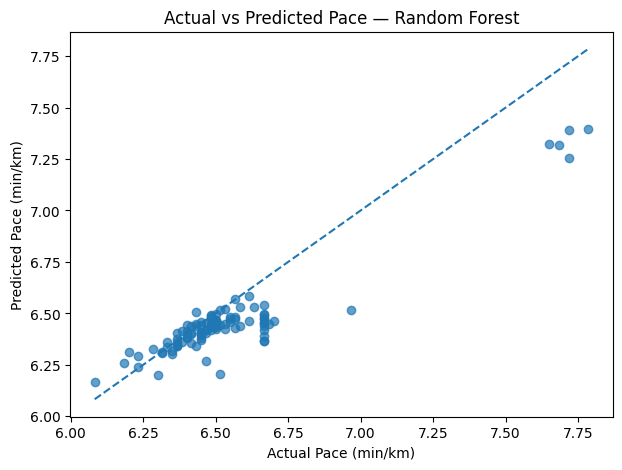

In [11]:
best_model_name = regression_results_df.loc[0, "Model"]
best_regression_model = trained_regression_models[best_model_name]

y_pred_best = best_regression_model.predict(X_test)

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_best, alpha=0.7)

min_value = min(y_test.min(), y_pred_best.min())
max_value = max(y_test.max(), y_pred_best.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.xlabel("Actual Pace (min/km)")
plt.ylabel("Predicted Pace (min/km)")
plt.title(f"Actual vs Predicted Pace — {best_model_name}")
plt.show()


## 9. Feature importance

For the best tree-based model, we can inspect which features were most important.

This helps connect the ML model back to the project question:

> Which activity features are most related to running performance?

Important note: feature importance shows association, not causation.


,Feature,Importance
0,Avg Run Cadence,0.898845
1,Avg Stride Length,0.029933
2,Distance,0.024021
3,days_since_start,0.018550
4,Number of Laps,0.007634
5,Max HR,0.004176
6,Max Run Cadence,0.003936
7,Avg HR,0.001713
8,Avg Power,0.001470
9,year,0.001323


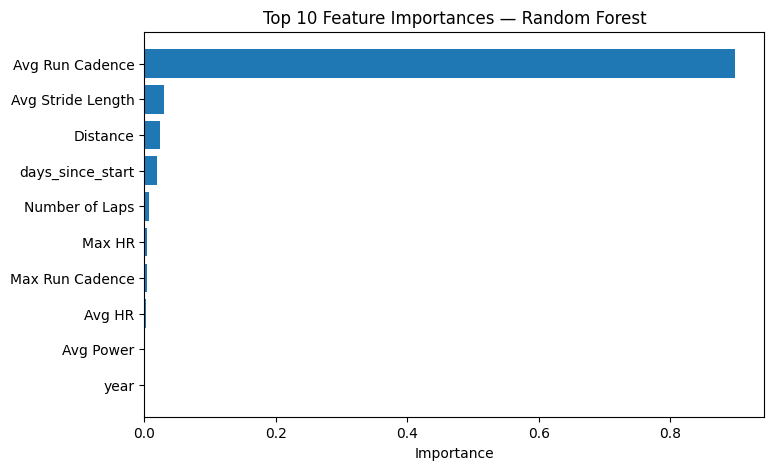

In [12]:
# Feature importance works directly for tree-based models such as Random Forest.
tree_model_name = "Random Forest"
tree_pipeline = trained_regression_models[tree_model_name]
tree_model = tree_pipeline.named_steps["model"]
preprocess_step = tree_pipeline.named_steps["preprocess"]

# Get transformed feature names
onehot_names = list(
    preprocess_step
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
)

all_feature_names = numeric_features + onehot_names

importance_df = (
    pd.DataFrame({
        "Feature": all_feature_names,
        "Importance": tree_model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(importance_df.head(15))

plt.figure(figsize=(8, 5))
top_features = importance_df.head(10).sort_values("Importance")
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances — Random Forest")
plt.show()


## 10. Classification task: fast vs slow runs

To show a second ML method, we also create a classification task.

A run is labeled as:

- `fast_run = 1` if its pace is faster than or equal to the median pace
- `fast_run = 0` otherwise

For classification, we use a random stratified split so that the fast/slow balance is similar in both training and test sets.


In [13]:
# Classification target
pace_threshold = model_data[target].median()
model_data["fast_run"] = (model_data[target] <= pace_threshold).astype(int)

X_classification = model_data[feature_cols]
y_classification = model_data["fast_run"]

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_classification,
    y_classification,
    test_size=0.20,
    random_state=42,
    stratify=y_classification
)

print("Median pace threshold:", pace_threshold)
print("Class distribution:")
display(y_classification.value_counts(normalize=True).rename("proportion"))


Median pace threshold: 6.666666666666667
Class distribution:


,proportion
fast_run,
1,0.546169
0,0.453831


In [14]:
classification_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),
    "Random Forest Classifier": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        min_samples_leaf=3,
        class_weight="balanced"
    )
}

classification_results = []
trained_classification_models = {}

for model_name, model in classification_models.items():
    pipeline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train_cls, y_train_cls)
    y_pred_cls = pipeline.predict(X_test_cls)

    classification_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test_cls, y_pred_cls),
        "Precision": precision_score(y_test_cls, y_pred_cls, zero_division=0),
        "Recall": recall_score(y_test_cls, y_pred_cls, zero_division=0),
        "F1": f1_score(y_test_cls, y_pred_cls, zero_division=0)
    })

    trained_classification_models[model_name] = pipeline

classification_results_df = (
    pd.DataFrame(classification_results)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

classification_results_df


,Model,Accuracy,Precision,Recall,F1
0,Random Forest Classifier,0.931373,0.929825,0.946429,0.938053
1,Logistic Regression,0.921569,0.900000,0.964286,0.931034


In [15]:
# Confusion matrix for the best classification model

best_classifier_name = classification_results_df.loc[0, "Model"]
best_classifier = trained_classification_models[best_classifier_name]

y_pred_cls_best = best_classifier.predict(X_test_cls)

cm = confusion_matrix(y_test_cls, y_pred_cls_best)
cm_df = pd.DataFrame(
    cm,
    index=["Actual Slow", "Actual Fast"],
    columns=["Predicted Slow", "Predicted Fast"]
)

print("Best classifier:", best_classifier_name)
display(cm_df)

print("\nClassification report:")
print(classification_report(y_test_cls, y_pred_cls_best, target_names=["Slow", "Fast"]))


Best classifier: Random Forest Classifier


,Predicted Slow,Predicted Fast
Actual Slow,42,4
Actual Fast,3,53



Classification report:
              precision    recall  f1-score   support

        Slow       0.93      0.91      0.92        46
        Fast       0.93      0.95      0.94        56

    accuracy                           0.93       102
   macro avg       0.93      0.93      0.93       102
weighted avg       0.93      0.93      0.93       102



## 11. Interpretation

The regression task predicts the exact pace of a run. The classification task predicts whether a run is relatively fast or slow.

In this dataset, tree-based models such as Random Forest and Gradient Boosting are expected to perform better than simple linear models because running performance is affected by non-linear relationships among cadence, distance, heart rate, stride length, training consistency, and activity type.

The model results should be interpreted carefully:

- The dataset is personal, so it may not generalize to other runners.
- Some features are measured during the run, so the model explains performance better than it predicts future performance before the run.
- Feature importance does not prove causation.
- The dataset is relatively small for machine learning, so simpler models are preferred over deep learning.
